# Libraries

In [1]:
# Data Preparation
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
from transformers import AutoTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Device

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


# Data Preprocessing & Preparation

In [14]:
stop_words_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

from transformers import AutoTokenizer, AutoModel
# Load DeBERTa tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("distilroberta-base")
model = AutoModel.from_pretrained("distilroberta-base")

def embedding(sentences, max_len=64):
    """
    Tokenize and encode sentences into DeBERTa embeddings.
    """
    # Tokenize input
    inputs = tokenizer(sentences, return_tensors='pt', padding=True, truncation=True, max_length=max_len)

    # Get DeBERTa embeddings
    with torch.no_grad():
        outputs = model(**inputs)

    # Extract [CLS]-like token (DeBERTa uses first token)
    return outputs.last_hidden_state[:, 0, :]

In [15]:
from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# Preprocessing pipelien
transform_pipeline = preprocessing.Compose([
    preprocessing.Lowercase()
    #preprocessing.Tokenize(tokenizer),
    #preprocessing.StopwordsRemoval(stop_words_list),
    #preprocessing.POStagging(),
    #preprocessing.Lemmatization(lemmatizer), 
])

In [16]:
# 1. Load dataset and apply prior Transform 
train_dataset = IMDBDataset(base_path='aclImdb', size=2000, train=True, transform=transform_pipeline)
test_dataset = IMDBDataset(base_path='aclImdb', size=1000, train=False, transform=transform_pipeline)
print(train_dataset.df.head())

# 2. Extract preprocessed texts and labels
train_input = [train_dataset[i][0] for i in range(len(train_dataset))]
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

test_input = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

# 3. Apply BERT Embeddings to the whole dataset
train_embedded_features = embedding(train_input)
test_embedded_features = embedding(test_input)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# 5. Construct dataset for dataloader
train_dataset = torch.utils.data.TensorDataset(train_embedded_features, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(test_embedded_features, y_test_tensor)

      id                                             review  score sentiment
0  12084  A toothsome little potboiler whose 65-minute l...      8  positive
1  12141  Of the three remakes on W. Somerset Maughan's ...      8  positive
2   9922  This is the most recent addition to a new wave...     10  positive
3   6764  In Where The Sidewalk Ends, Otto Preminger reu...      9  positive
4  10943  I have to vote this 10 out of 10 in the rare c...     10  positive


/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_16004/3393106566.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_16004/3393106566.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)


# Split data for training and validation

In [17]:
# Split train_dataset into training and validation set
from sklearn.model_selection import train_test_split

#Split dataset for train and validation
train_size = int(0.8 * len(train_dataset))
train_indices, val_indices = train_test_split(list(range(len(train_dataset))),
                                              test_size=len(train_dataset) - train_size,
                                              stratify=y_train_tensor,
                                              random_state=42)

trainset = torch.utils.data.Subset(train_dataset, train_indices)
valset = torch.utils.data.Subset(train_dataset, val_indices)

#DataLoader to handle batching and shuffling
batch_size = 32
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Model

# Training + Evaluation

In [18]:
from train_test import train_model, test_model, plot_accuracy_loss, plot_confusion_matrix
import classifier as clf

# init paramètre
nb_epochs = 64
optimizer = 'Adam'
lr = 0.001

SimpleClassifier(
  (fc1): Linear(in_features=768, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


38552 total parameters.
38552 training parameters.




  3%|▎         | 2/64 [00:00<00:03, 18.35it/s]

| Epoch: [1/64] | Train: Loss 0.6807 Accuracy : 0.5631 | Val: Loss 0.6771 Accuracy : 0.5050

| Epoch: [2/64] | Train: Loss 0.6411 Accuracy : 0.6863 | Val: Loss 0.6483 Accuracy : 0.5975

| Epoch: [3/64] | Train: Loss 0.5864 Accuracy : 0.7338 | Val: Loss 0.6154 Accuracy : 0.6700

| Epoch: [4/64] | Train: Loss 0.5405 Accuracy : 0.7525 | Val: Loss 0.5961 Accuracy : 0.7025



  9%|▉         | 6/64 [00:00<00:02, 26.22it/s]

| Epoch: [5/64] | Train: Loss 0.5128 Accuracy : 0.7706 | Val: Loss 0.5898 Accuracy : 0.6950

| Epoch: [6/64] | Train: Loss 0.4968 Accuracy : 0.7725 | Val: Loss 0.5870 Accuracy : 0.6900

| Epoch: [7/64] | Train: Loss 0.4864 Accuracy : 0.7769 | Val: Loss 0.5852 Accuracy : 0.7050



...

| Epoch: [56/64] | Train: Loss 0.3935 Accuracy : 0.8181 | Val: Loss 0.6112 Accuracy : 0.7175

| Epoch: [57/64] | Train: Loss 0.3926 Accuracy : 0.8194 | Val: Loss 0.6122 Accuracy : 0.7175

| Epoch: [58/64] | Train: Loss 0.3916 Accuracy : 0.8200 | Val: Loss 0.6131 Accuracy : 0.7150

| Epoch: [59/64] | Train: Loss 0.3907 Accuracy : 0.8187 | Val: Loss 0.6142 Accuracy : 0.7150

| Epoch: [60/64] | Train: Loss 0.3898 Accuracy : 0.8181 | Val: Loss 0.6152 Accuracy : 0.7150

| Epoch: [61/64] | Train: Loss 0.3890 Accuracy : 0.8181 | Val: Loss 0.6164 Accuracy : 0.7175



 97%|█████████▋| 62/64 [00:01<00:00, 33.42it/s]

| Epoch: [62/64] | Train: Loss 0.3881 Accuracy : 0.8200 | Val: Loss 0.6175 Accuracy : 0.7150



100%|██████████| 64/64 [00:01<00:00, 32.54it/s]


| Epoch: [63/64] | Train: Loss 0.3870 Accuracy : 0.8213 | Val: Loss 0.6184 Accuracy : 0.7150

| Epoch: [64/64] | Train: Loss 0.3862 Accuracy : 0.8219 | Val: Loss 0.6196 Accuracy : 0.7150


Test accuracy: 0.731


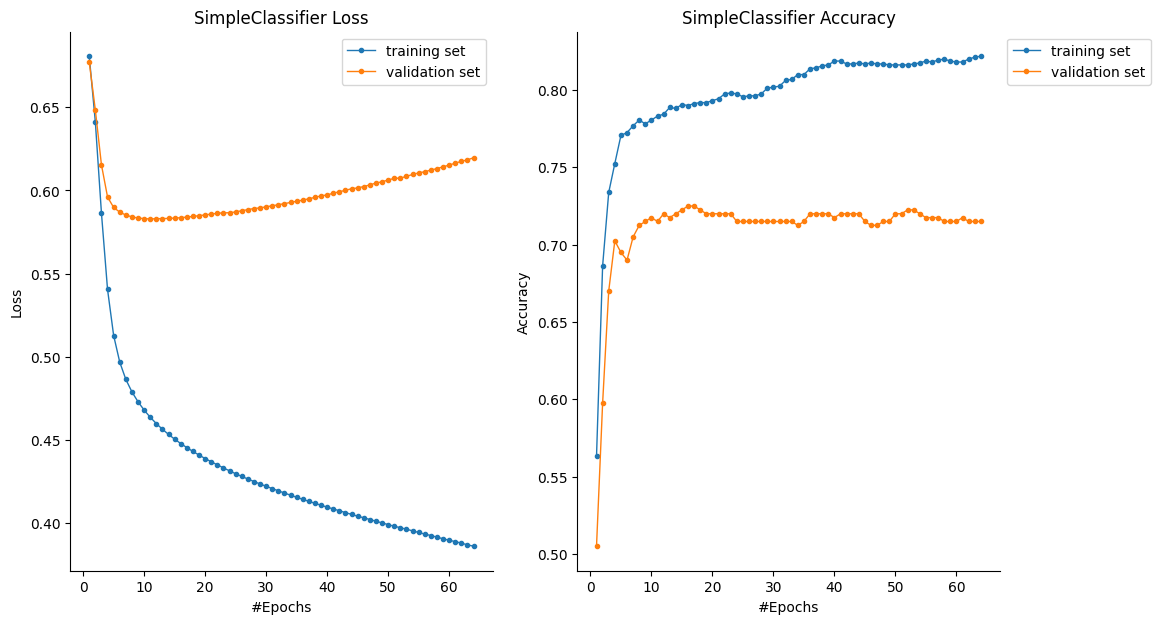

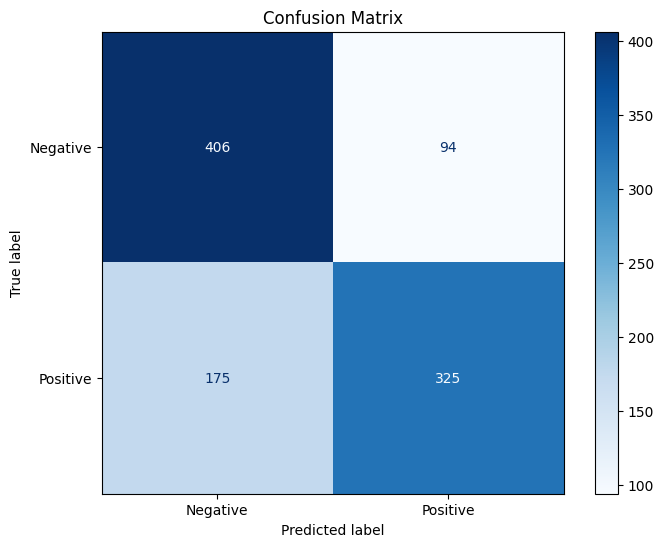

In [19]:
input_dim = train_dataset.tensors[0].shape[1]
model = clf.SimpleClassifier(input_dim=input_dim).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("SimpleClassifier", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# LSTM

LSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


592130 total parameters.
592130 training parameters.




  2%|▏         | 1/64 [00:00<00:09,  6.59it/s]

| Epoch: [1/64] | Train: Loss 0.6933 Accuracy : 0.4975 | Val: Loss 0.6877 Accuracy : 0.6875



  3%|▎         | 2/64 [00:00<00:09,  6.73it/s]

| Epoch: [2/64] | Train: Loss 0.6384 Accuracy : 0.6500 | Val: Loss 0.5879 Accuracy : 0.6925



...

| Epoch: [59/64] | Train: Loss 0.0618 Accuracy : 0.9700 | Val: Loss 1.7215 Accuracy : 0.7075

| Epoch: [60/64] | Train: Loss 0.0545 Accuracy : 0.9781 | Val: Loss 1.8340 Accuracy : 0.7050



 97%|█████████▋| 62/64 [00:08<00:00,  7.49it/s]

| Epoch: [61/64] | Train: Loss 0.0478 Accuracy : 0.9812 | Val: Loss 1.6610 Accuracy : 0.7150

| Epoch: [62/64] | Train: Loss 0.0506 Accuracy : 0.9781 | Val: Loss 2.0164 Accuracy : 0.6950



100%|██████████| 64/64 [00:08<00:00,  7.39it/s]

| Epoch: [63/64] | Train: Loss 0.0087 Accuracy : 0.9988 | Val: Loss 1.9814 Accuracy : 0.7075

| Epoch: [64/64] | Train: Loss 0.0068 Accuracy : 0.9994 | Val: Loss 1.9487 Accuracy : 0.7075


Test accuracy: 0.729


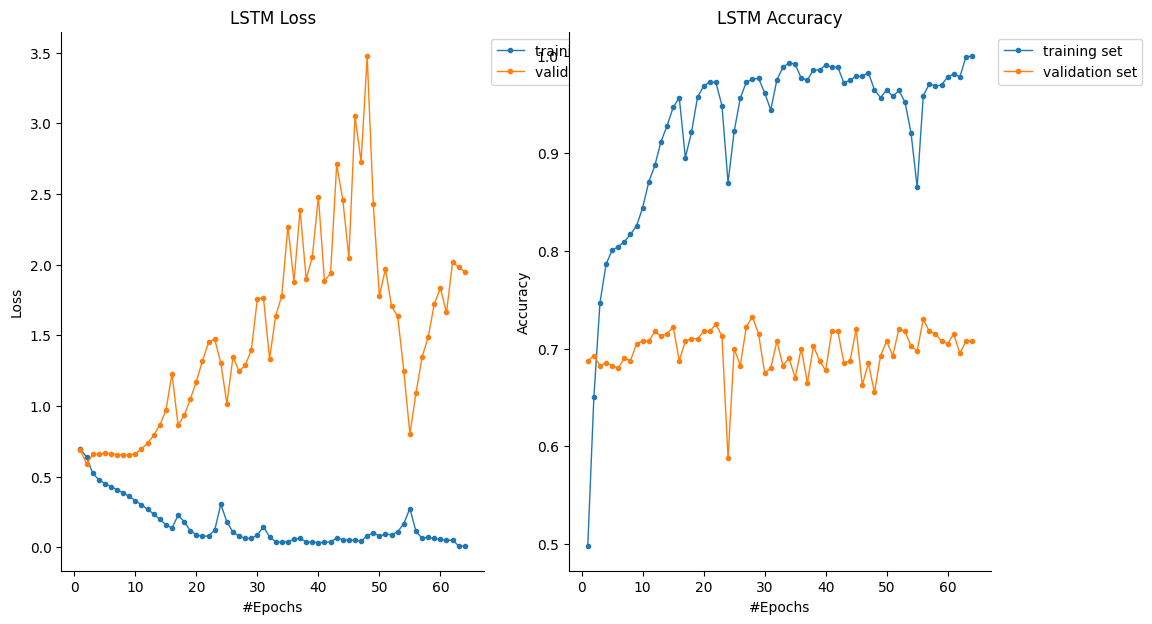

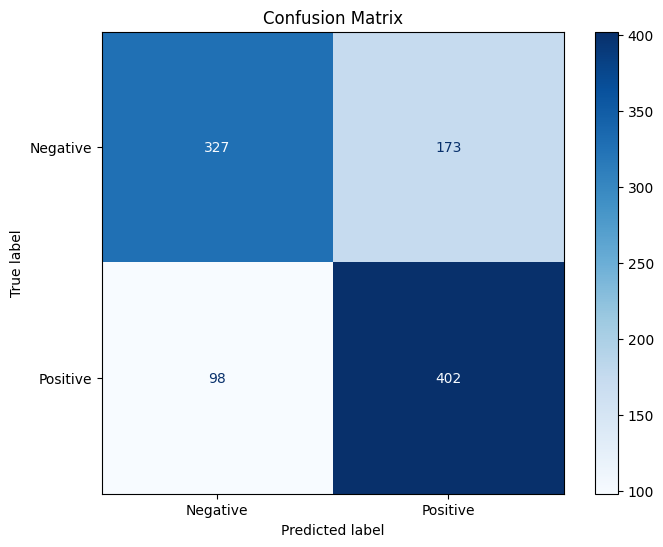

In [20]:
input_dim = train_embedded_features.shape[1]  
model = clf.LSTMClassifier(input_dim=input_dim, hidden_dim=128, num_layers=2, output_dim=2, bidirectional=False).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Deeper LSTM

DeepLSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1726658 total parameters.
1726658 training parameters.




  2%|▏         | 1/64 [00:00<00:20,  3.09it/s]

| Epoch: [1/64] | Train: Loss 0.6934 Accuracy : 0.4944 | Val: Loss 0.6927 Accuracy : 0.6375



  3%|▎         | 2/64 [00:00<00:24,  2.53it/s]

| Epoch: [2/64] | Train: Loss 0.6519 Accuracy : 0.6331 | Val: Loss 0.6787 Accuracy : 0.6225



...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.5812 Accuracy : 0.7200



 98%|█████████▊| 63/64 [00:20<00:00,  3.19it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.5898 Accuracy : 0.7200



100%|██████████| 64/64 [00:21<00:00,  3.02it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.5990 Accuracy : 0.7200


Test accuracy: 0.741


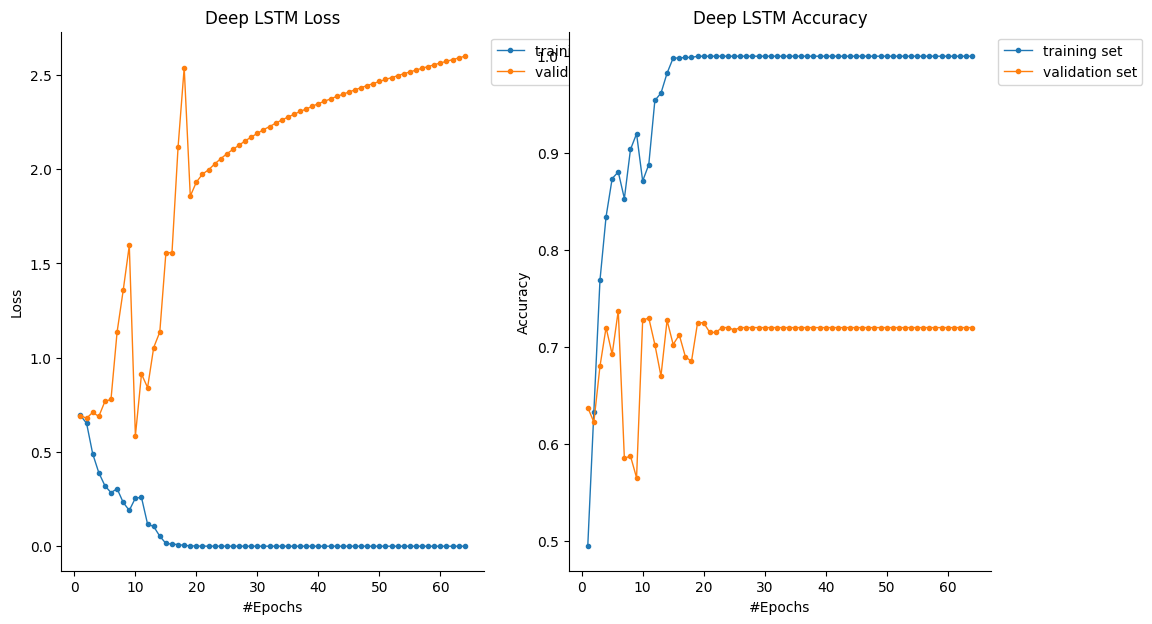

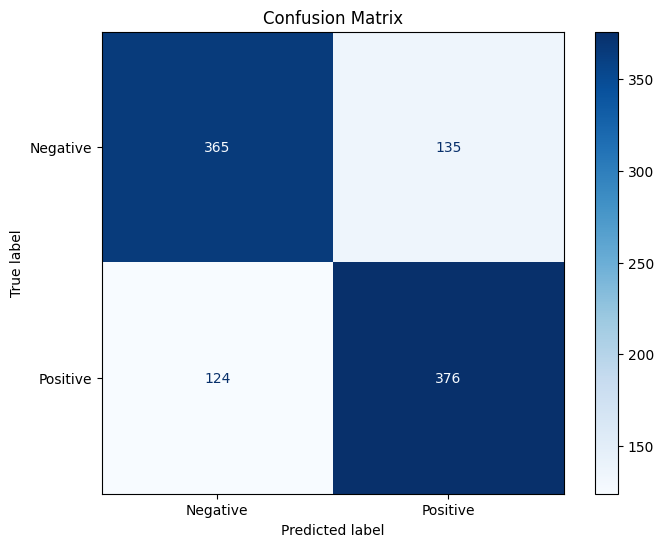

In [21]:
input_dim = X_train_tensor.shape[1]  
model = clf.DeepLSTMClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=3,
    fc_hidden_dim=64,
    output_dim=2,  # set this to the number of classes
    dropout=0.4,
    bidirectional=True
).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Deep LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Attention LSTM

LSTMWithAttentionClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1331651 total parameters.
1331651 training parameters.




  2%|▏         | 1/64 [00:00<00:16,  3.90it/s]

| Epoch: [1/64] | Train: Loss 0.6939 Accuracy : 0.5031 | Val: Loss 0.6901 Accuracy : 0.5025



  3%|▎         | 2/64 [00:00<00:15,  3.94it/s]

| Epoch: [2/64] | Train: Loss 0.6356 Accuracy : 0.6606 | Val: Loss 0.6189 Accuracy : 0.7000



...

| Epoch: [62/64] | Train: Loss 0.0003 Accuracy : 1.0000 | Val: Loss 2.3387 Accuracy : 0.7150



 98%|█████████▊| 63/64 [00:16<00:00,  3.88it/s]

| Epoch: [63/64] | Train: Loss 0.0002 Accuracy : 1.0000 | Val: Loss 2.3625 Accuracy : 0.7175



100%|██████████| 64/64 [00:17<00:00,  3.75it/s]

| Epoch: [64/64] | Train: Loss 0.0002 Accuracy : 1.0000 | Val: Loss 2.3805 Accuracy : 0.7150


Test accuracy: 0.729


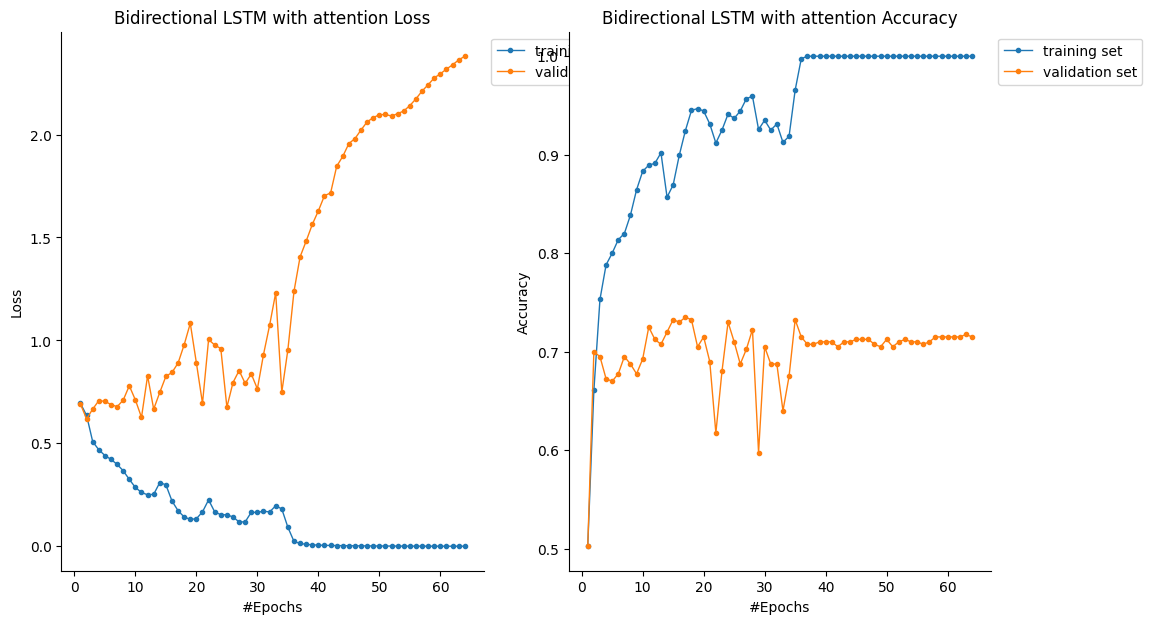

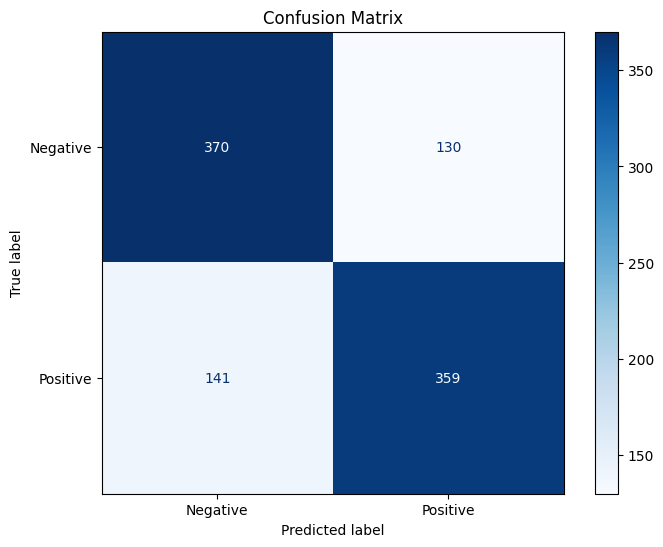

In [22]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMWithAttentionClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=2,
    output_dim=2,
    dropout=0.3,
    fc_hidden_dim=64,
    bidirectional=True
).to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Bidirectional LSTM with attention", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])